# Visualizations for LLM notebook

In [46]:
# Cell 1: Setup, Imports, and Data Loading
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# THESIS COLOR SCHEME
# =============================================================================
COLORS = {
    'primary': '#4682B4',      # Steel Blue
    'secondary': '#FF7F50',    # Coral Orange
    'accent1': '#5A9BD4',      # Light Steel Blue
    'accent2': '#f7c4ab',      # Light Coral
    'dark': '#2F5496',         # Dark Steel Blue
    'text': '#333333',         # Dark Gray
    'light': '#B0C4DE',        # Light Steel Blue (muted)
}

MODEL_ABBREV = {
    'deepseek-r1': 'DeepSeek-R1',
    'gemini-2.5-flash-lite': 'Gemini-2.5',
    'gpt-4.1-mini': 'GPT-4.1-mini',
    'gpt-4.1-nano': 'GPT-4.1-nano',
    'gpt-oss-120b': 'GPT-OSS-120B',
    'gpt-oss-20b': 'GPT-OSS-20B',
    'grok-4-fast': 'Grok-4',
    'llama-3.1-405b-instruct': 'Llama-405B',
    'meta-llama-3-1-70b-instruct': 'Llama-70B',
    'meta-llama-3-1-8b-instruct': 'Llama-8B',
    'qwen3-14b': 'Qwen3-14B',
    'qwen3-32b': 'Qwen3-32B',
}

def get_model_abbrev(model_name):
    """Get abbreviation for model name, or return original if not found"""
    return MODEL_ABBREV.get(model_name, model_name)

# Palette for 12 models (alternating steel blue and coral variations)
PALETTE_MAIN = ['#4682B4', '#FF7F50', '#5A9BD4', '#FF9966',
                '#6495ED', '#FFA07A', '#87CEEB', '#FA8072', 
                '#4169E1', '#CD5C5C', '#2F5496', '#E9967A']

# Set matplotlib style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'normal'  # Ensure axis labels are not bold

# =============================================================================
# LOAD DATA
# =============================================================================
RESULTS_DIR = Path('../results')
OUTPUT_DIR = RESULTS_DIR / 'final_visualizations'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load both result files
df_targetonly = pd.read_csv(RESULTS_DIR / 'all_results_targetonly_rerank_edited_threshold.csv')
df_withsub = pd.read_csv(RESULTS_DIR / 'all_results_withsub_rerank_edited_threshold.csv') 
# Combine into single dataframe
df = pd.concat([df_targetonly, df_withsub], ignore_index=True)

print(f"Loaded {len(df_targetonly)} targetonly records and {len(df_withsub)} withsub records")
print(f"Total: {len(df)} records")
print(f"Models: {df['model'].nunique()} - {sorted(df['model'].unique())}")

# =============================================================================
# PARSE JSON COLUMNS AND EXTRACT METRICS
# =============================================================================
def safe_json_parse(x):
    """Safely parse JSON string"""
    if pd.isna(x):
        return {}
    try:
        if isinstance(x, dict):
            return x
        return json.loads(x)
    except:
        return {}

# Parse judge columns
df['judge_baseline_parsed'] = df['judge_baseline'].apply(safe_json_parse)
df['judge_embedding_parsed'] = df['judge_embedding'].apply(safe_json_parse)
df['judge_rerank_parsed'] = df['judge_rerank'].apply(safe_json_parse)
# Extract judge average scores
df['judge_baseline_avg'] = df['judge_baseline_parsed'].apply(lambda x: x.get('average', np.nan))
df['judge_embedding_avg'] = df['judge_embedding_parsed'].apply(lambda x: x.get('average', np.nan))
df['judge_rerank_avg'] = df['judge_rerank_parsed'].apply(lambda x: x.get('average', np.nan))
# Extract individual judge scores
df['baseline_coherence'] = df['judge_baseline_parsed'].apply(lambda x: x.get('coherence', np.nan))
df['baseline_mapping'] = df['judge_baseline_parsed'].apply(lambda x: x.get('mapping', np.nan))
df['baseline_explanatory'] = df['judge_baseline_parsed'].apply(lambda x: x.get('explanatory', np.nan))

df['embedding_coherence'] = df['judge_embedding_parsed'].apply(lambda x: x.get('coherence', np.nan))
df['embedding_mapping'] = df['judge_embedding_parsed'].apply(lambda x: x.get('mapping', np.nan))
df['embedding_explanatory'] = df['judge_embedding_parsed'].apply(lambda x: x.get('explanatory', np.nan))

df['rerank_coherence'] = df['judge_rerank_parsed'].apply(lambda x: x.get('coherence', np.nan))
df['rerank_mapping'] = df['judge_rerank_parsed'].apply(lambda x: x.get('mapping', np.nan))
df['rerank_explanatory'] = df['judge_rerank_parsed'].apply(lambda x: x.get('explanatory', np.nan))

# =============================================================================
# COMPUTE HIT@K METRICS
# =============================================================================
def compute_hit_at_k(ranks_col, k):
    """Compute Hit@K: percentage where best_rank <= k and rank != -1"""
    valid = (ranks_col >= 1) & (ranks_col <= k)
    return valid.sum() / len(ranks_col) * 100

# Add Hit@K columns
for k in [1, 3, 5, 10, 20]:
    df[f'hit_exact_{k}'] = ((df['best_exact_rank'] >= 1) & (df['best_exact_rank'] <= k)).astype(int)
    df[f'hit_sem_{k}'] = ((df['best_sem_rank'] >= 1) & (df['best_sem_rank'] <= k)).astype(int)

# Failure indicator
df['exact_match_found'] = (df['best_exact_rank'] >= 1).astype(int)
df['sem_match_found'] = (df['best_sem_rank'] >= 1).astype(int)

print("\nData preparation complete!")
print(f"Judge Baseline Avg - Mean: {df['judge_baseline_avg'].mean():.3f}, Valid: {df['judge_baseline_avg'].notna().sum()}")
print(f"Judge Embedding Avg - Mean: {df['judge_embedding_avg'].mean():.3f}, Valid: {df['judge_embedding_avg'].notna().sum()}")
print(f"Judge Rerank Avg - Mean: {df['judge_rerank_avg'].mean():.3f}, Valid: {df['judge_rerank_avg'].notna().sum()}")

Loaded 3737 targetonly records and 3850 withsub records
Total: 7587 records
Models: 12 - ['deepseek-r1', 'gemini-2.5-flash-lite', 'gpt-4.1-mini', 'gpt-4.1-nano', 'gpt-oss-120b', 'gpt-oss-20b', 'grok-4-fast', 'llama-3.1-405b-instruct', 'meta-llama-3-1-70b-instruct', 'meta-llama-3-1-8b-instruct', 'qwen3-14b', 'qwen3-32b']

Data preparation complete!
Judge Baseline Avg - Mean: 2.604, Valid: 7587
Judge Embedding Avg - Mean: 2.342, Valid: 7587
Judge Rerank Avg - Mean: 2.813, Valid: 7585


### Target Only VS Target with Sub-concept

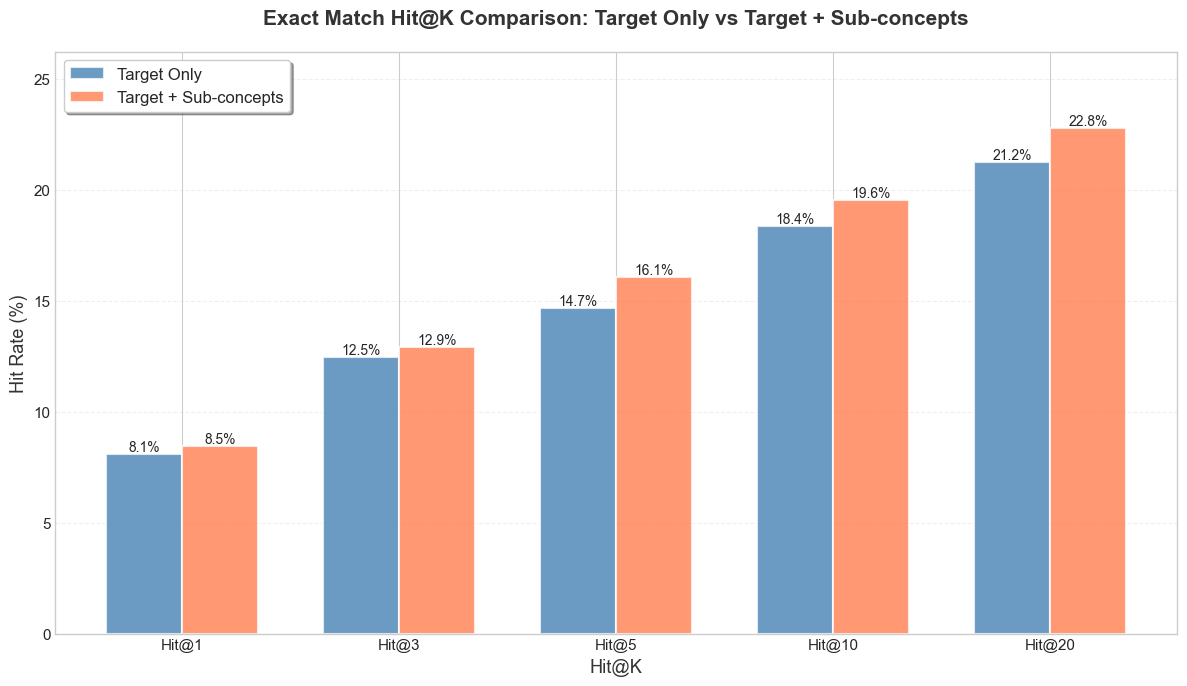

Exact Match Hit@K Comparison by Mode (Aggregated)
Hit@1: Target Only = 8.11%, Target+Sub = 8.47%, Difference = +0.36%
Hit@3: Target Only = 12.47%, Target+Sub = 12.94%, Difference = +0.47%
Hit@5: Target Only = 14.69%, Target+Sub = 16.08%, Difference = +1.39%
Hit@10: Target Only = 18.38%, Target+Sub = 19.56%, Difference = +1.17%
Hit@20: Target Only = 21.25%, Target+Sub = 22.81%, Difference = +1.56%


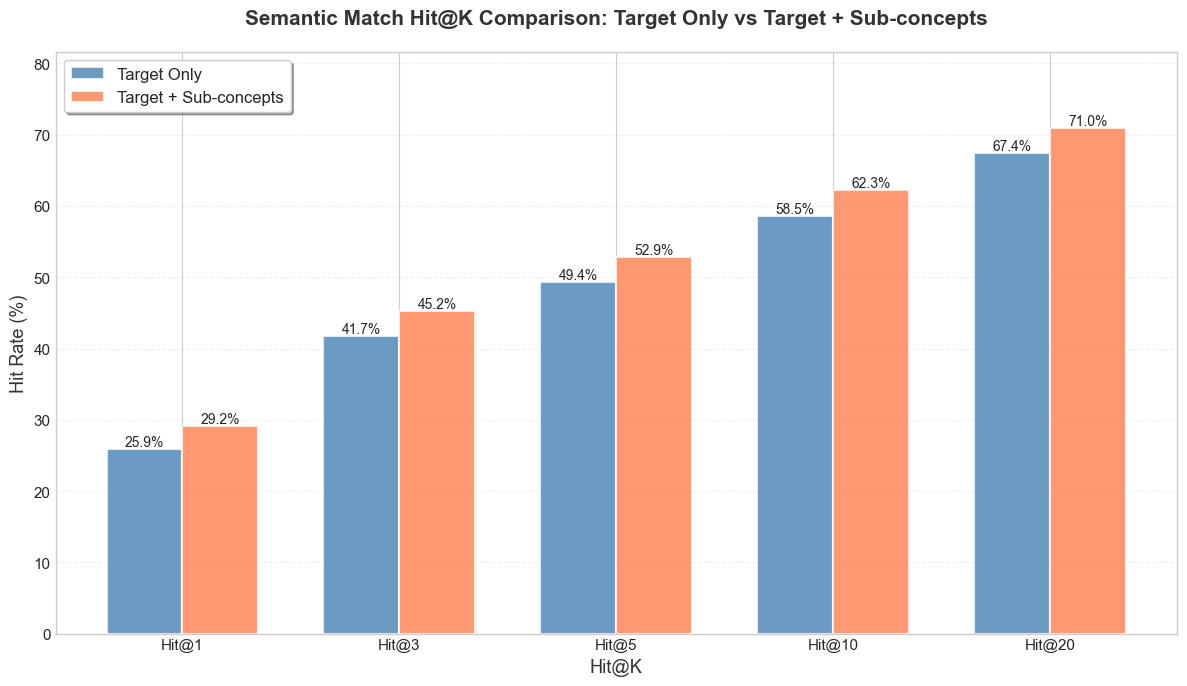


Semantic Match Hit@K Comparison by Mode (Aggregated)
Hit@1: Target Only = 25.90%, Target+Sub = 29.19%, Difference = +3.29%
Hit@3: Target Only = 41.72%, Target+Sub = 45.22%, Difference = +3.50%
Hit@5: Target Only = 49.37%, Target+Sub = 52.86%, Difference = +3.49%
Hit@10: Target Only = 58.52%, Target+Sub = 62.26%, Difference = +3.74%
Hit@20: Target Only = 67.38%, Target+Sub = 70.99%, Difference = +3.61%


In [47]:
# =============================================================================
# VISUALIZATION 1A: Exact Hit@K Comparison by Mode (Aggregated Across Models)
# =============================================================================

# Calculate Exact Hit@K metrics aggregated by mode
hit_k_values = [1, 3, 5, 10, 20]
mode_comparison = []

for mode in ['targetonly', 'withsub']:
    mode_df = df[df['mode'] == mode]
    mode_data = {'mode': mode}
    for k in hit_k_values:
        hit_rate = mode_df[f'hit_exact_{k}'].mean() * 100
        mode_data[f'Hit@{k}'] = hit_rate
    mode_comparison.append(mode_data)

mode_df_plot = pd.DataFrame(mode_comparison)

# Create comparison plot for Exact Match
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(hit_k_values))
width = 0.35

bars1 = ax.bar(x - width/2, mode_df_plot[mode_df_plot['mode'] == 'targetonly'].iloc[0][[f'Hit@{k}' for k in hit_k_values]].values,
               width, label='Target Only', color=COLORS['primary'], alpha=0.8, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, mode_df_plot[mode_df_plot['mode'] == 'withsub'].iloc[0][[f'Hit@{k}' for k in hit_k_values]].values,
               width, label='Target + Sub-concepts', color=COLORS['secondary'], alpha=0.8, edgecolor='white', linewidth=1.5)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10)

add_value_labels(bars1)
add_value_labels(bars2)

ax.set_xlabel('Hit@K', fontsize=13, color=COLORS['text'])
ax.set_ylabel('Hit Rate (%)', fontsize=13, color=COLORS['text'])
ax.set_title('Exact Match Hit@K Comparison: Target Only vs Target + Sub-concepts', 
             fontsize=15, fontweight='bold', color=COLORS['text'], pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'Hit@{k}' for k in hit_k_values], fontsize=11)
ax.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(mode_df_plot[[f'Hit@{k}' for k in hit_k_values]].max()) * 1.15)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hit_k_exact_mode_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*70)
print("Exact Match Hit@K Comparison by Mode (Aggregated)")
print("="*70)
for k in hit_k_values:
    to_val = mode_df_plot[mode_df_plot['mode'] == 'targetonly'].iloc[0][f'Hit@{k}']
    ws_val = mode_df_plot[mode_df_plot['mode'] == 'withsub'].iloc[0][f'Hit@{k}']
    diff = ws_val - to_val
    print(f"Hit@{k}: Target Only = {to_val:.2f}%, Target+Sub = {ws_val:.2f}%, Difference = {diff:+.2f}%")

# =============================================================================
# VISUALIZATION 1B: Semantic Hit@K Comparison by Mode (Aggregated Across Models)
# =============================================================================

# Calculate Semantic Hit@K metrics aggregated by mode
mode_comparison_sem = []

for mode in ['targetonly', 'withsub']:
    mode_df = df[df['mode'] == mode]
    mode_data = {'mode': mode}
    for k in hit_k_values:
        # Use semantic matches (with threshold 0.374)
        hit_rate = mode_df[f'hit_sem_{k}'].mean() * 100
        mode_data[f'Hit@{k}'] = hit_rate
    mode_comparison_sem.append(mode_data)

mode_df_plot_sem = pd.DataFrame(mode_comparison_sem)

# Create comparison plot for Semantic Match
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(hit_k_values))
width = 0.35

bars1 = ax.bar(x - width/2, mode_df_plot_sem[mode_df_plot_sem['mode'] == 'targetonly'].iloc[0][[f'Hit@{k}' for k in hit_k_values]].values,
               width, label='Target Only', color=COLORS['primary'], alpha=0.8, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, mode_df_plot_sem[mode_df_plot_sem['mode'] == 'withsub'].iloc[0][[f'Hit@{k}' for k in hit_k_values]].values,
               width, label='Target + Sub-concepts', color=COLORS['secondary'], alpha=0.8, edgecolor='white', linewidth=1.5)

# Add value labels on bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10)

add_value_labels(bars1)
add_value_labels(bars2)

ax.set_xlabel('Hit@K', fontsize=13, color=COLORS['text'])
ax.set_ylabel('Hit Rate (%)', fontsize=13, color=COLORS['text'])
ax.set_title('Semantic Match Hit@K Comparison: Target Only vs Target + Sub-concepts', 
             fontsize=15, fontweight='bold', color=COLORS['text'], pad=20)
ax.set_xticks(x)
ax.set_xticklabels([f'Hit@{k}' for k in hit_k_values], fontsize=11)
ax.legend(loc='upper left', fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(mode_df_plot_sem[[f'Hit@{k}' for k in hit_k_values]].max()) * 1.15)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hit_k_semantic_mode_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("Semantic Match Hit@K Comparison by Mode (Aggregated)")
print("="*70)
for k in hit_k_values:
    to_val = mode_df_plot_sem[mode_df_plot_sem['mode'] == 'targetonly'].iloc[0][f'Hit@{k}']
    ws_val = mode_df_plot_sem[mode_df_plot_sem['mode'] == 'withsub'].iloc[0][f'Hit@{k}']
    diff = ws_val - to_val
    print(f"Hit@{k}: Target Only = {to_val:.2f}%, Target+Sub = {ws_val:.2f}%, Difference = {diff:+.2f}%")

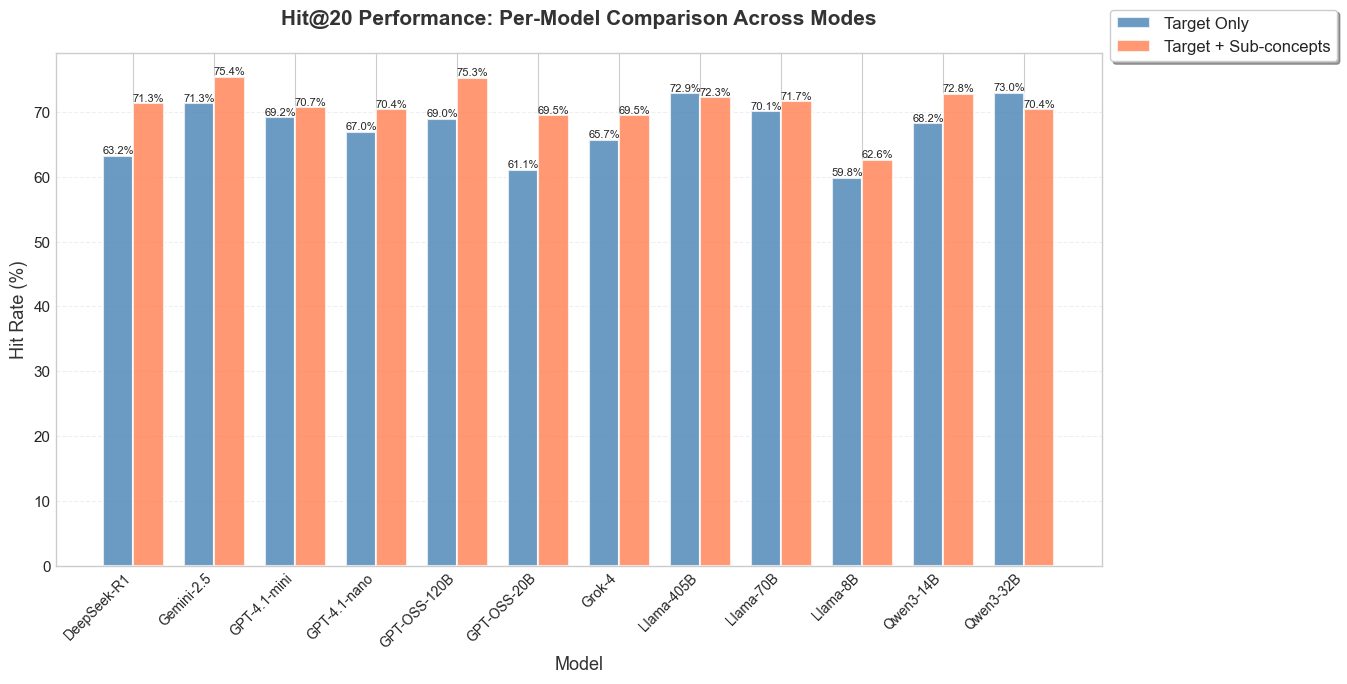


Per-Model Hit@20 Summary

TARGETONLY Mode:
                  model    Hit@20
              qwen3-32b 72.985782
llama-3.1-405b-instruct 72.897196
  gemini-2.5-flash-lite 71.339564

WITHSUB Mode:
                model    Hit@20
gemini-2.5-flash-lite 75.389408
         gpt-oss-120b 75.312500
            qwen3-14b 72.812500


In [48]:
# =============================================================================
# VISUALIZATION 2: Per-Model Hit@20 Performance by Mode
# =============================================================================

# Calculate Hit@20 for each model and mode
models = sorted(df['model'].unique())
model_mode_data = []

for model in models:
    for mode in ['targetonly', 'withsub']:
        model_mode_df = df[(df['model'] == model) & (df['mode'] == mode)]
        if len(model_mode_df) > 0:
            hit_rate = model_mode_df['hit_sem_20'].mean() * 100
            model_mode_data.append({'model': model, 'mode': mode, 'Hit@20': hit_rate})

model_mode_df = pd.DataFrame(model_mode_data)

# Create single figure for Hit@20 - increase width
fig, ax = plt.subplots(figsize=(16, 7))  # Increased from (14, 7) - wider figure

# Prepare data
to_data = model_mode_df[model_mode_df['mode'] == 'targetonly'].set_index('model')['Hit@20']
ws_data = model_mode_df[model_mode_df['mode'] == 'withsub'].set_index('model')['Hit@20']

# Ensure both have same models and apply abbreviations
all_models = sorted(set(to_data.index) | set(ws_data.index))
all_models_abbrev = [get_model_abbrev(m) for m in all_models]
to_values = [to_data.get(m, 0) for m in all_models]
ws_values = [ws_data.get(m, 0) for m in all_models]

# Increase spacing between bar groups
x = np.arange(len(all_models)) * 1.2  # Multiply by 1.2 or 1.5 to increase spacing
width = 0.45  # Thicker bars

bars1 = ax.bar(x - width/2, to_values, width, label='Target Only', 
               color=COLORS['primary'], alpha=0.8, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x + width/2, ws_values, width, label='Target + Sub-concepts', 
               color=COLORS['secondary'], alpha=0.8, edgecolor='white', linewidth=1.5)

ax.set_xlabel('Model', fontsize=13, color=COLORS['text'])
ax.set_ylabel('Hit Rate (%)', fontsize=13, color=COLORS['text'])
ax.set_title('Hit@20 Performance: Per-Model Comparison Across Modes', 
             fontsize=15, fontweight='bold', color=COLORS['text'], pad=20)
ax.set_xticks(x)  # Use the spaced x positions
ax.set_xticklabels(all_models_abbrev, rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.0, 1.1), frameon=True, fancybox=True, shadow=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
# Add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.5:  # Only label if > 0.5%
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1f}%',
                   ha='center', va='bottom', fontsize=8)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make room for legend on the right
plt.savefig(OUTPUT_DIR / 'hit_20_per_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "="*70)
print("Per-Model Hit@20 Summary")
print("="*70)
for mode in ['targetonly', 'withsub']:
    print(f"\n{mode.upper()} Mode:")
    mode_data = model_mode_df[model_mode_df['mode'] == mode].copy()
    top_models = mode_data.nlargest(3, 'Hit@20')[['model', 'Hit@20']]
    print(top_models.to_string(index=False))

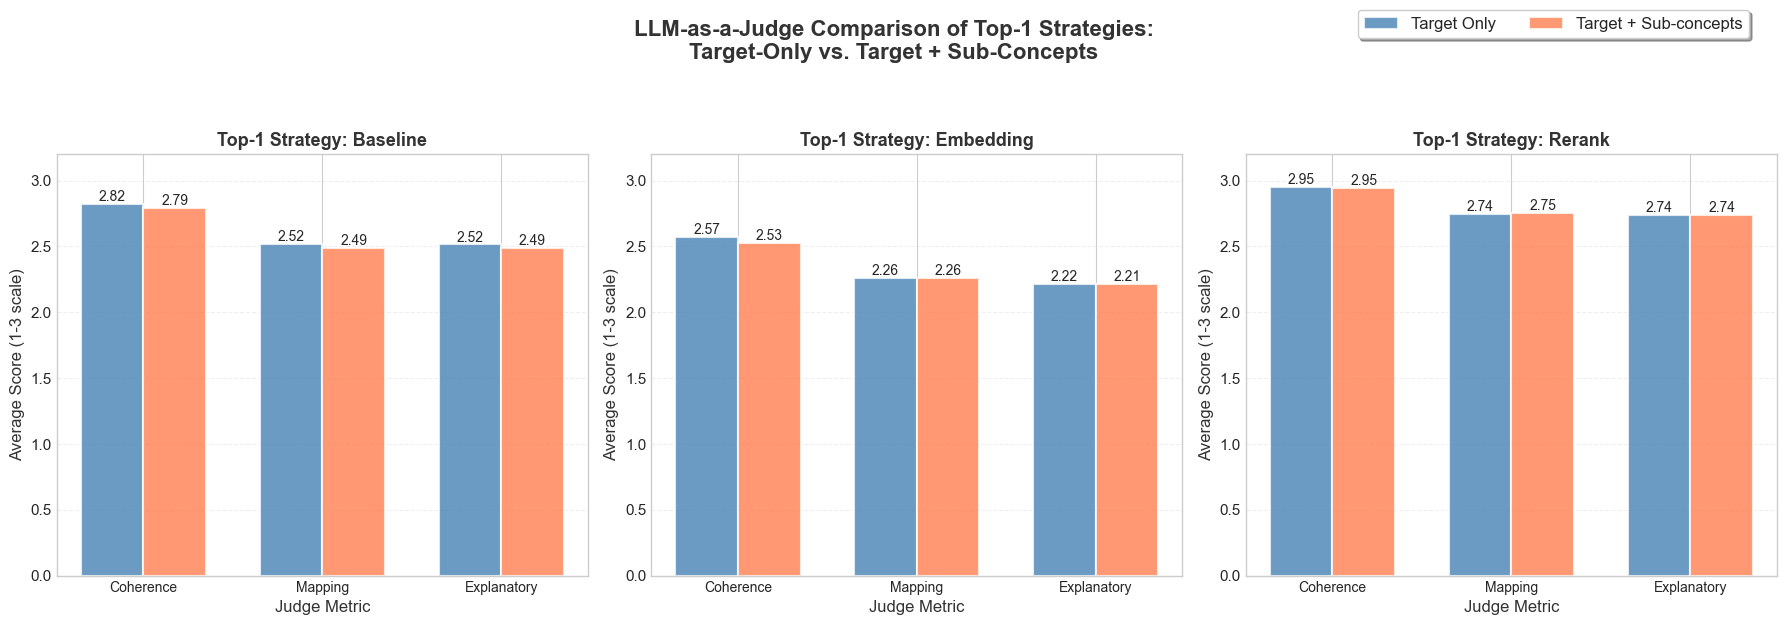


LLM-as-a-Judge Comparison by Mode (Aggregated)

BASELINE Method:
  Coherence: Target Only = 2.822, Target+Sub = 2.791, Difference = -0.031
  Mapping: Target Only = 2.518, Target+Sub = 2.492, Difference = -0.027
  Explanatory: Target Only = 2.515, Target+Sub = 2.492, Difference = -0.023

EMBEDDING Method:
  Coherence: Target Only = 2.574, Target+Sub = 2.529, Difference = -0.046
  Mapping: Target Only = 2.260, Target+Sub = 2.263, Difference = +0.002
  Explanatory: Target Only = 2.215, Target+Sub = 2.215, Difference = -0.001

RERANK Method:
  Coherence: Target Only = 2.954, Target+Sub = 2.948, Difference = -0.006
  Mapping: Target Only = 2.744, Target+Sub = 2.754, Difference = +0.010
  Explanatory: Target Only = 2.737, Target+Sub = 2.739, Difference = +0.002


In [49]:

# Calculate judge scores aggregated by mode
judge_metrics = ['coherence', 'mapping', 'explanatory', 'average']
judge_methods = ['baseline', 'embedding', 'rerank']

mode_judge_comparison = []

for mode in ['targetonly', 'withsub']:
    mode_df = df[df['mode'] == mode]
    mode_data = {'mode': mode}
    
    for method in judge_methods:
        for metric in judge_metrics:
            col_name = f'{method}_{metric}'
            if col_name in mode_df.columns:
                mean_score = mode_df[col_name].mean()
                mode_data[f'{method}_{metric}'] = mean_score
    
    mode_judge_comparison.append(mode_data)

judge_df = pd.DataFrame(mode_judge_comparison)

# Create comparison plots for each judge method
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, method in enumerate(judge_methods):
    ax = axes[idx]
    
    # Get data for this method
    metrics_to_plot = [f'{method}_{m}' for m in judge_metrics if f'{method}_{m}' in judge_df.columns]
    metric_labels = [m.replace(f'{method}_', '').title() for m in metrics_to_plot]
    
    to_values = [judge_df[judge_df['mode'] == 'targetonly'].iloc[0][m] for m in metrics_to_plot]
    ws_values = [judge_df[judge_df['mode'] == 'withsub'].iloc[0][m] for m in metrics_to_plot]
    
    x = np.arange(len(metric_labels))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, to_values, width, label='Target Only', 
                   color=COLORS['primary'], alpha=0.8, edgecolor='white', linewidth=1.5)
    bars2 = ax.bar(x + width/2, ws_values, width, label='Target + Sub-concepts', 
                   color=COLORS['secondary'], alpha=0.8, edgecolor='white', linewidth=1.5)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}',
                   ha='center', va='bottom', fontsize=10)
    
    ax.set_xlabel('Judge Metric', fontsize=12, color=COLORS['text'])
    ax.set_ylabel('Average Score (1-3 scale)', fontsize=12, color=COLORS['text'])
    ax.set_title(f'Top-1 Strategy: {method.title()}', fontsize=13, fontweight='bold', color=COLORS['text'])
    ax.set_xticks(x)
    ax.set_xticklabels(metric_labels, fontsize=10)
    # Remove individual legend - we'll add one shared legend
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 3.2)

# Create a single shared legend for the entire figure
fig.legend([bars1, bars2], ['Target Only', 'Target + Sub-concepts'], 
           loc='upper right', bbox_to_anchor=(0.98, 1.05), 
           fontsize=12, frameon=True, fancybox=True, shadow=True, ncol=2)

plt.suptitle('LLM-as-a-Judge Comparison of Top-1 Strategies:\nTarget-Only vs. Target + Sub-Concepts', 
             fontsize=16, fontweight='bold', color=COLORS['text'], y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(OUTPUT_DIR / 'llm_judge_mode_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*70)
print("LLM-as-a-Judge Comparison by Mode (Aggregated)")
print("="*70)
for method in judge_methods:
    print(f"\n{method.upper()} Method:")
    for metric in judge_metrics:
        col = f'{method}_{metric}'
        if col in judge_df.columns:
            to_val = judge_df[judge_df['mode'] == 'targetonly'].iloc[0][col]
            ws_val = judge_df[judge_df['mode'] == 'withsub'].iloc[0][col]
            diff = ws_val - to_val
            print(f"  {metric.title()}: Target Only = {to_val:.3f}, Target+Sub = {ws_val:.3f}, Difference = {diff:+.3f}")

### Best selecting Strategy

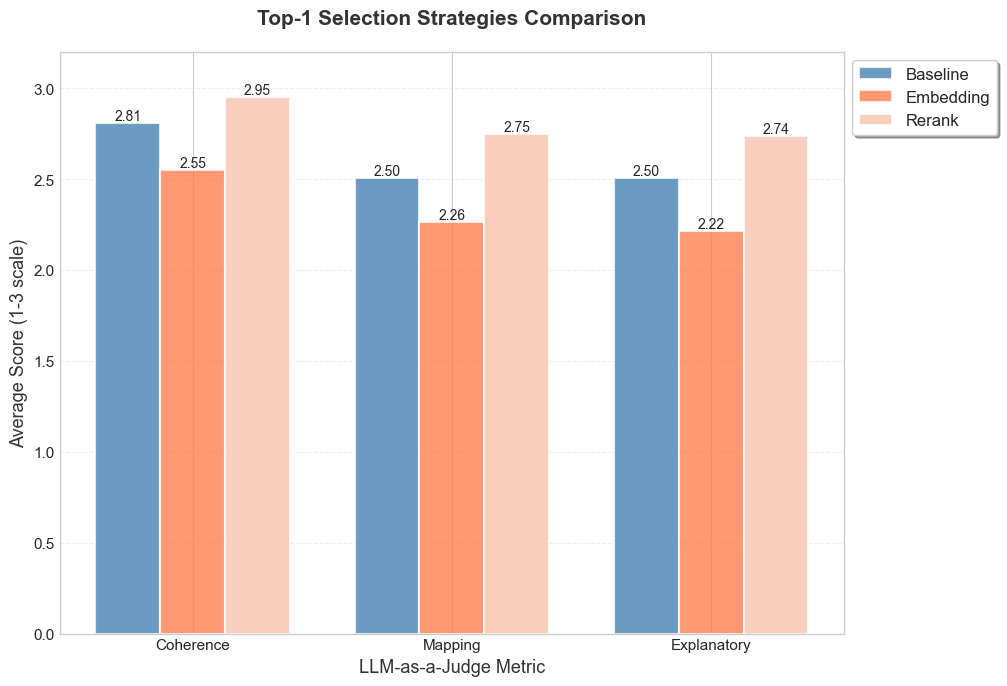

Top-1 Selection Strategies Comparison (Aggregated)

BASELINE Strategy:
  Coherence: 2.806
  Mapping: 2.505
  Explanatory: 2.503

EMBEDDING Strategy:
  Coherence: 2.551
  Mapping: 2.261
  Explanatory: 2.215

RERANK Strategy:
  Coherence: 2.951
  Mapping: 2.749
  Explanatory: 2.738


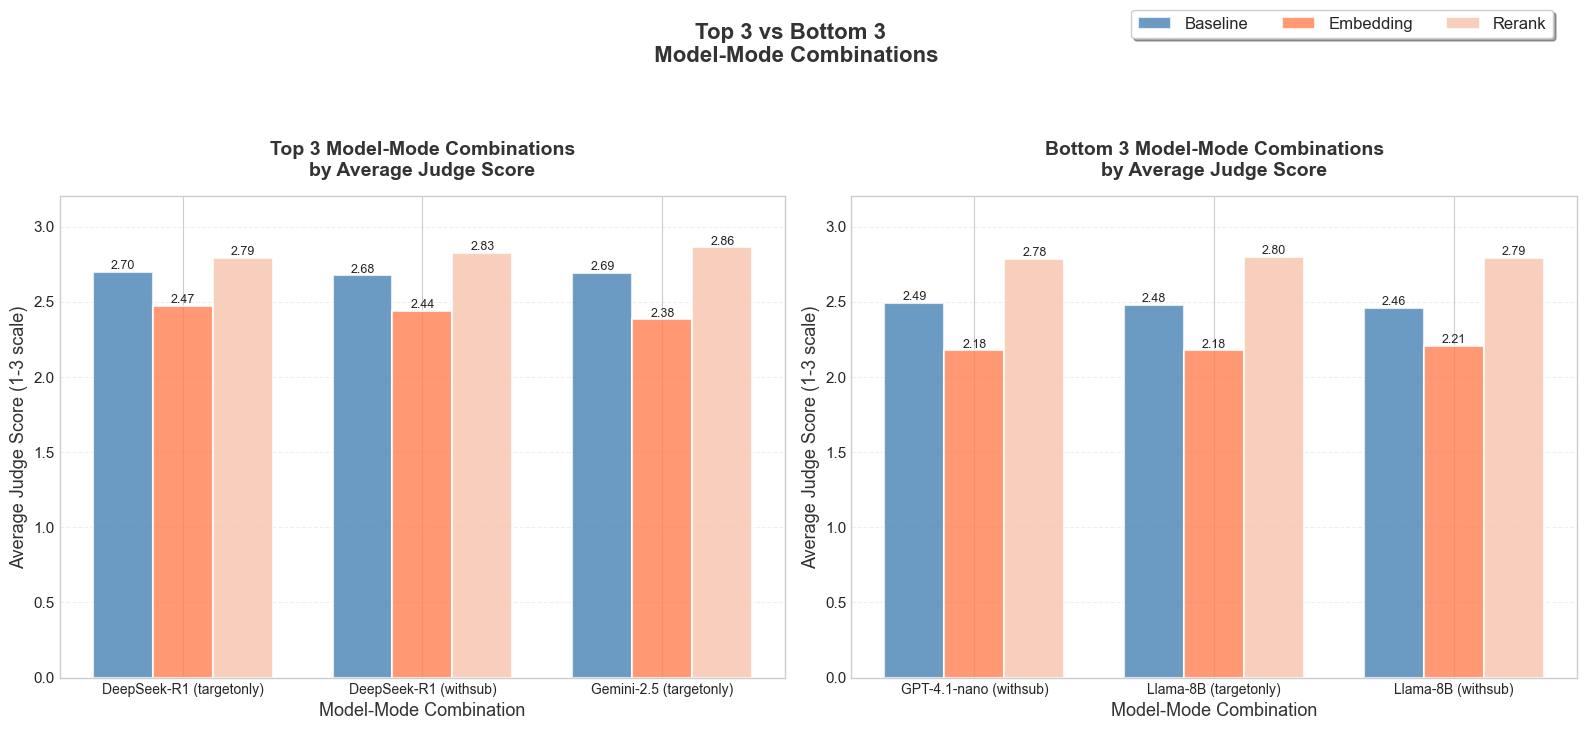


Top 3 Model-Mode Combinations

DeepSeek-R1 (targetonly):
  Baseline: 2.696
  Embedding: 2.470
  Rerank: 2.790
  Overall Average: 2.652

DeepSeek-R1 (withsub):
  Baseline: 2.675
  Embedding: 2.442
  Rerank: 2.827
  Overall Average: 2.648

Gemini-2.5 (targetonly):
  Baseline: 2.690
  Embedding: 2.383
  Rerank: 2.862
  Overall Average: 2.645

Bottom 3 Model-Mode Combinations

GPT-4.1-nano (withsub):
  Baseline: 2.495
  Embedding: 2.176
  Rerank: 2.783
  Overall Average: 2.484

Llama-8B (targetonly):
  Baseline: 2.478
  Embedding: 2.176
  Rerank: 2.799
  Overall Average: 2.484

Llama-8B (withsub):
  Baseline: 2.457
  Embedding: 2.208
  Rerank: 2.790
  Overall Average: 2.485


In [50]:
# =============================================================================
# VISUALIZATION 5: Top-1 Selection Strategies Comparison (Aggregated Across Models)
# =============================================================================

# Calculate judge scores for each top-1 strategy aggregated across all models
judge_metrics = ['coherence', 'mapping', 'explanatory']
top1_strategies = ['baseline', 'embedding', 'rerank']

strategy_comparison = []

for strategy in top1_strategies:
    strategy_data = {'strategy': strategy}
    for metric in judge_metrics:
        col_name = f'{strategy}_{metric}'
        if col_name in df.columns:
            mean_score = df[col_name].mean()
            strategy_data[metric] = mean_score
    strategy_comparison.append(strategy_data)

strategy_df = pd.DataFrame(strategy_comparison)

# Create comparison plot
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(judge_metrics))
width = 0.25

strategies_data = []
for strategy in top1_strategies:
    strategy_row = strategy_df[strategy_df['strategy'] == strategy].iloc[0]
    values = [strategy_row[m] for m in judge_metrics]
    strategies_data.append(values)

bars1 = ax.bar(x - width, strategies_data[0], width, label='Baseline', 
               color=COLORS['primary'], alpha=0.8, edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x, strategies_data[1], width, label='Embedding', 
               color=COLORS['secondary'], alpha=0.8, edgecolor='white', linewidth=1.5)
bars3 = ax.bar(x + width, strategies_data[2], width, label='Rerank', 
               color=COLORS['accent2'], alpha=0.8, edgecolor='white', linewidth=1.5)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.2f}',
               ha='center', va='bottom', fontsize=10)

ax.set_xlabel('LLM-as-a-Judge Metric', fontsize=13, color=COLORS['text'])
ax.set_ylabel('Average Score (1-3 scale)', fontsize=13, color=COLORS['text'])
ax.set_title('Top-1 Selection Strategies Comparison', 
             fontsize=15, fontweight='bold', color=COLORS['text'], pad=20)
ax.set_xticks(x)
ax.set_xticklabels([m.title() for m in judge_metrics], fontsize=11)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=12, frameon=True, fancybox=True, shadow=True)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, 3.2)

plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make room for legend on the right
plt.savefig(OUTPUT_DIR / 'top1_strategies_comparison_aggregated.png', dpi=300, bbox_inches='tight')
plt.show()

print("="*70)
print("Top-1 Selection Strategies Comparison (Aggregated)")
print("="*70)
for strategy in top1_strategies:
    strategy_row = strategy_df[strategy_df['strategy'] == strategy].iloc[0]
    print(f"\n{strategy.upper()} Strategy:")
    for metric in judge_metrics:
        print(f"  {metric.title()}: {strategy_row[metric]:.3f}")

# =============================================================================
# VISUALIZATION 6: Per-Model Top-1 Strategies Comparison (Top 3 and Bottom 3)
# =============================================================================

# Calculate average judge score for each model-mode-strategy combination
model_strategy_data = []

for model in sorted(df['model'].unique()):
    for mode in ['targetonly', 'withsub']:
        model_mode_df = df[(df['model'] == model) & (df['mode'] == mode)]
        if len(model_mode_df) > 0:
            row_data = {
                'model': model,
                'mode': mode,
                'model_mode': f"{get_model_abbrev(model)} ({mode})"
            }
            for strategy in top1_strategies:
                col_name = f'judge_{strategy}_avg'
                if col_name in model_mode_df.columns:
                    avg_score = model_mode_df[col_name].mean()
                    row_data[f'{strategy}_avg'] = avg_score
            model_strategy_data.append(row_data)

model_strategy_df = pd.DataFrame(model_strategy_data)

# Calculate overall average for each model-mode combination
model_strategy_df['overall_avg'] = model_strategy_df[[f'{s}_avg' for s in top1_strategies]].mean(axis=1)

# Get top 3 and bottom 3
top3 = model_strategy_df.nlargest(3, 'overall_avg')
bottom3 = model_strategy_df.nsmallest(3, 'overall_avg')

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Top 3 models
x_top = np.arange(len(top3))
width = 0.25

baseline_top = [top3.iloc[i][f'baseline_avg'] for i in range(len(top3))]
embedding_top = [top3.iloc[i][f'embedding_avg'] for i in range(len(top3))]
rerank_top = [top3.iloc[i][f'rerank_avg'] for i in range(len(top3))]

bars1_top = ax1.bar(x_top - width, baseline_top, width, label='Baseline', 
                    color=COLORS['primary'], alpha=0.8, edgecolor='white', linewidth=1.5)
bars2_top = ax1.bar(x_top, embedding_top, width, label='Embedding', 
                    color=COLORS['secondary'], alpha=0.8, edgecolor='white', linewidth=1.5)
bars3_top = ax1.bar(x_top + width, rerank_top, width, label='Rerank', 
                    color=COLORS['accent2'], alpha=0.8, edgecolor='white', linewidth=1.5)

# Add value labels
for bars in [bars1_top, bars2_top, bars3_top]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Model-Mode Combination', fontsize=13, color=COLORS['text'])
ax1.set_ylabel('Average Judge Score (1-3 scale)', fontsize=13, color=COLORS['text'])
ax1.set_title('Top 3 Model-Mode Combinations\nby Average Judge Score', 
              fontsize=14, fontweight='bold', color=COLORS['text'], pad=15)
ax1.set_xticks(x_top)
ax1.set_xticklabels([top3.iloc[i]['model_mode'] for i in range(len(top3))], 
                     rotation=0, ha='center', fontsize=10)
# Remove individual legend - we'll add one shared legend
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim(0, 3.2)

# Bottom 3 models
x_bottom = np.arange(len(bottom3))

baseline_bottom = [bottom3.iloc[i][f'baseline_avg'] for i in range(len(bottom3))]
embedding_bottom = [bottom3.iloc[i][f'embedding_avg'] for i in range(len(bottom3))]
rerank_bottom = [bottom3.iloc[i][f'rerank_avg'] for i in range(len(bottom3))]

bars1_bottom = ax2.bar(x_bottom - width, baseline_bottom, width, label='Baseline', 
                       color=COLORS['primary'], alpha=0.8, edgecolor='white', linewidth=1.5)
bars2_bottom = ax2.bar(x_bottom, embedding_bottom, width, label='Embedding', 
                       color=COLORS['secondary'], alpha=0.8, edgecolor='white', linewidth=1.5)
bars3_bottom = ax2.bar(x_bottom + width, rerank_bottom, width, label='Rerank', 
                       color=COLORS['accent2'], alpha=0.8, edgecolor='white', linewidth=1.5)

# Add value labels
for bars in [bars1_bottom, bars2_bottom, bars3_bottom]:
    for bar in bars:
        height = bar.get_height()
        if not np.isnan(height):
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2f}',
                    ha='center', va='bottom', fontsize=9)

ax2.set_xlabel('Model-Mode Combination', fontsize=13, color=COLORS['text'])
ax2.set_ylabel('Average Judge Score (1-3 scale)', fontsize=13, color=COLORS['text'])
ax2.set_title('Bottom 3 Model-Mode Combinations\nby Average Judge Score', 
              fontsize=14, fontweight='bold', color=COLORS['text'], pad=15)
ax2.set_xticks(x_bottom)
ax2.set_xticklabels([bottom3.iloc[i]['model_mode'] for i in range(len(bottom3))], 
                     rotation=0, ha='center', fontsize=10)
# Remove individual legend - we'll add one shared legend
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_ylim(0, 3.2)

# Create a single shared legend for the entire figure
fig.legend([bars1_top, bars2_top, bars3_top], ['Baseline', 'Embedding', 'Rerank'], 
           loc='upper right', bbox_to_anchor=(0.98, 1.05), 
           fontsize=12, frameon=True, fancybox=True, shadow=True, ncol=3)

plt.suptitle('Top 3 vs Bottom 3 \n Model-Mode Combinations', 
             fontsize=16, fontweight='bold', color=COLORS['text'], y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjusted for shared legend
plt.savefig(OUTPUT_DIR / 'top1_strategies_per_model_top_bottom.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary
print("\n" + "="*70)
print("Top 3 Model-Mode Combinations")
print("="*70)
for idx, row in top3.iterrows():
    print(f"\n{row['model_mode']}:")
    print(f"  Baseline: {row['baseline_avg']:.3f}")
    print(f"  Embedding: {row['embedding_avg']:.3f}")
    print(f"  Rerank: {row['rerank_avg']:.3f}")
    print(f"  Overall Average: {row['overall_avg']:.3f}")

print("\n" + "="*70)
print("Bottom 3 Model-Mode Combinations")
print("="*70)
for idx, row in bottom3.iterrows():
    print(f"\n{row['model_mode']}:")
    print(f"  Baseline: {row['baseline_avg']:.3f}")
    print(f"  Embedding: {row['embedding_avg']:.3f}")
    print(f"  Rerank: {row['rerank_avg']:.3f}")
    print(f"  Overall Average: {row['overall_avg']:.3f}")


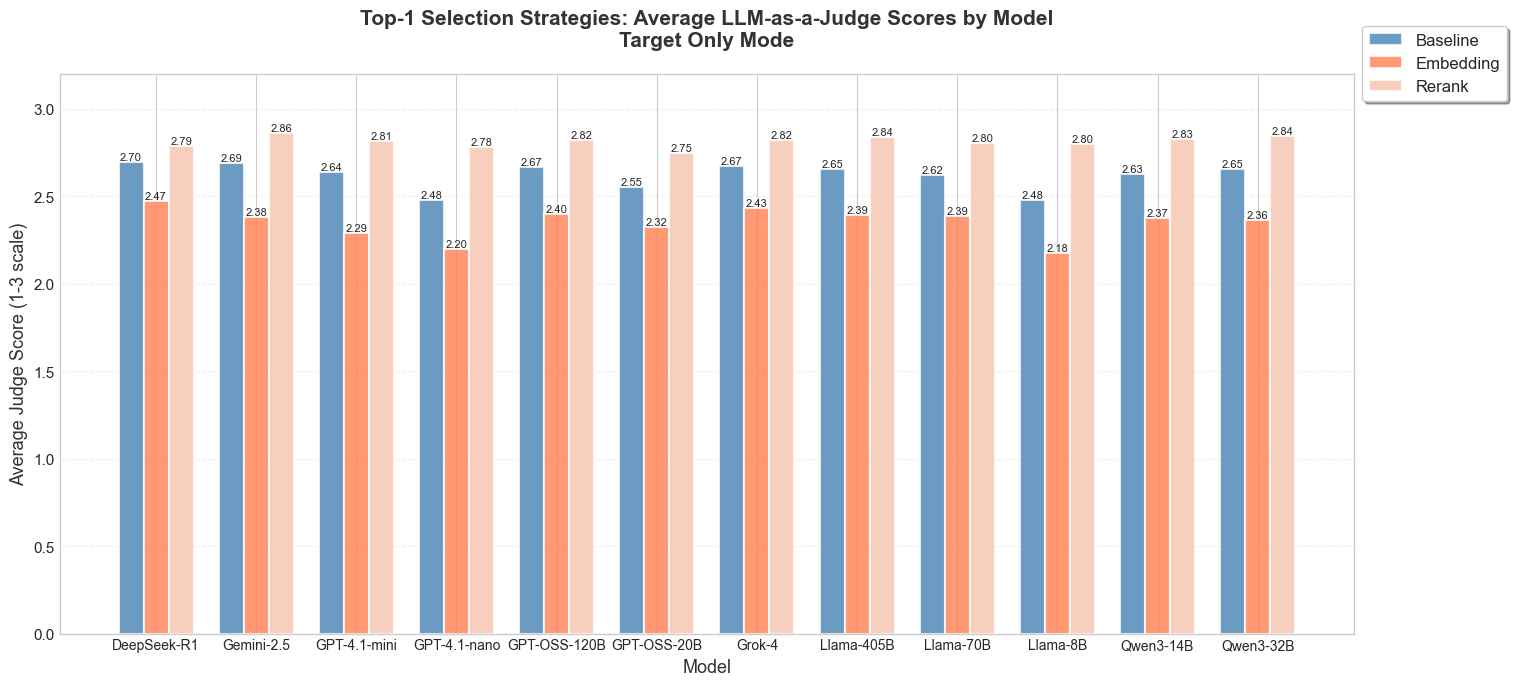


Top-1 Selection Strategies by Model - Target Only Mode

DeepSeek-R1:
  Baseline: 2.696
  Embedding: 2.470
  Rerank: 2.790

Gemini-2.5:
  Baseline: 2.690
  Embedding: 2.383
  Rerank: 2.862

GPT-4.1-mini:
  Baseline: 2.637
  Embedding: 2.292
  Rerank: 2.814

GPT-4.1-nano:
  Baseline: 2.480
  Embedding: 2.198
  Rerank: 2.781

GPT-OSS-120B:
  Baseline: 2.667
  Embedding: 2.401
  Rerank: 2.822

GPT-OSS-20B:
  Baseline: 2.551
  Embedding: 2.323
  Rerank: 2.748

Grok-4:
  Baseline: 2.671
  Embedding: 2.432
  Rerank: 2.823

Llama-405B:
  Baseline: 2.653
  Embedding: 2.394
  Rerank: 2.839

Llama-70B:
  Baseline: 2.620
  Embedding: 2.390
  Rerank: 2.802

Llama-8B:
  Baseline: 2.478
  Embedding: 2.176
  Rerank: 2.799

Qwen3-14B:
  Baseline: 2.630
  Embedding: 2.374
  Rerank: 2.828

Qwen3-32B:
  Baseline: 2.653
  Embedding: 2.363
  Rerank: 2.843


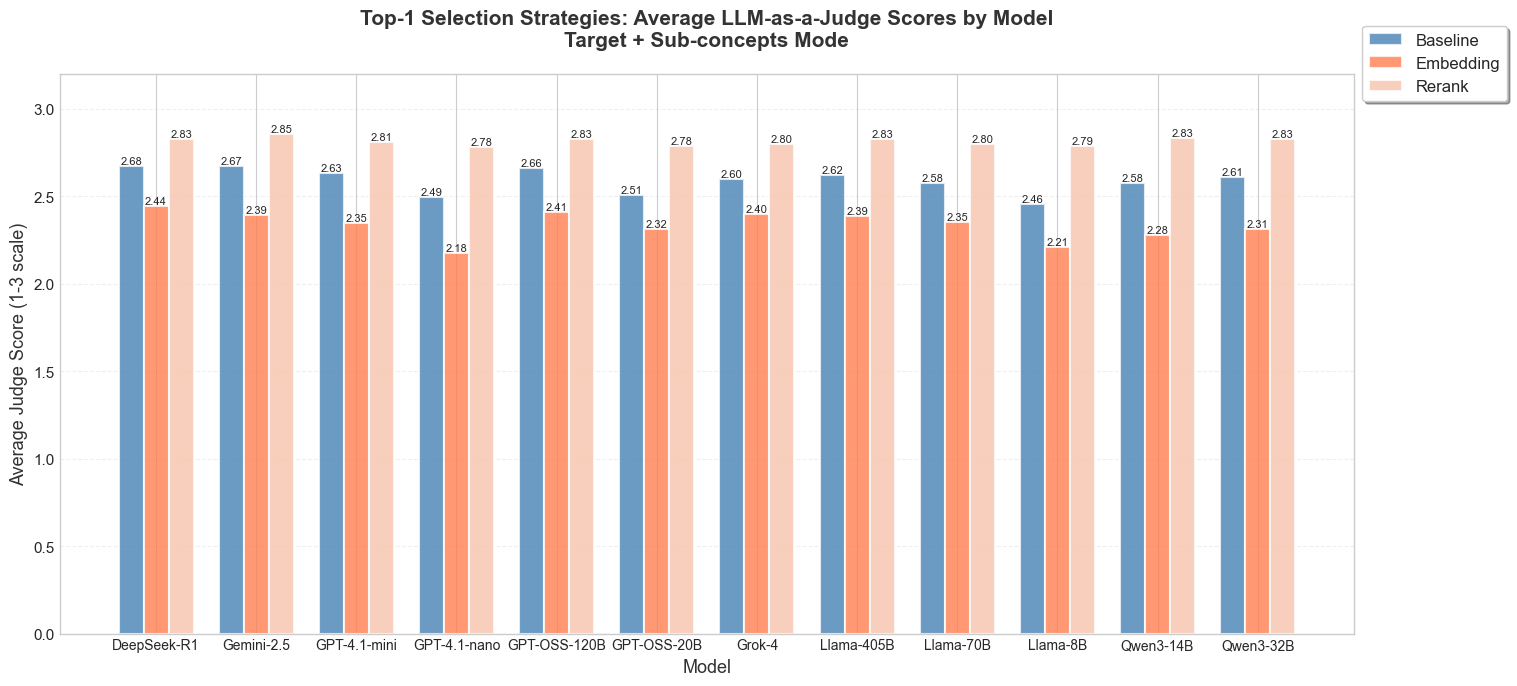


Top-1 Selection Strategies by Model - Target + Sub-concepts Mode

DeepSeek-R1:
  Baseline: 2.675
  Embedding: 2.442
  Rerank: 2.827

Gemini-2.5:
  Baseline: 2.671
  Embedding: 2.392
  Rerank: 2.853

GPT-4.1-mini:
  Baseline: 2.633
  Embedding: 2.345
  Rerank: 2.807

GPT-4.1-nano:
  Baseline: 2.495
  Embedding: 2.176
  Rerank: 2.783

GPT-OSS-120B:
  Baseline: 2.664
  Embedding: 2.410
  Rerank: 2.828

GPT-OSS-20B:
  Baseline: 2.507
  Embedding: 2.315
  Rerank: 2.785

Grok-4:
  Baseline: 2.600
  Embedding: 2.397
  Rerank: 2.800

Llama-405B:
  Baseline: 2.624
  Embedding: 2.386
  Rerank: 2.828

Llama-70B:
  Baseline: 2.575
  Embedding: 2.354
  Rerank: 2.800

Llama-8B:
  Baseline: 2.457
  Embedding: 2.208
  Rerank: 2.790

Qwen3-14B:
  Baseline: 2.576
  Embedding: 2.280
  Rerank: 2.833

Qwen3-32B:
  Baseline: 2.611
  Embedding: 2.312
  Rerank: 2.826


In [54]:
# =============================================================================
# VISUALIZATION 7: Per-Model Top-1 Strategies Comparison by Mode
# =============================================================================

# Calculate average judge score for each model and strategy, separated by mode
top1_strategies = ['baseline', 'embedding', 'rerank']

for mode in ['targetonly', 'withsub']:
    mode_df = df[df['mode'] == mode]
    models = sorted(mode_df['model'].unique())
    
    # Prepare data
    model_strategy_data = []
    for model in models:
        model_df = mode_df[mode_df['model'] == model]
        row_data = {'model': model, 'model_abbrev': get_model_abbrev(model)}
        for strategy in top1_strategies:
            col_name = f'judge_{strategy}_avg'
            if col_name in model_df.columns:
                avg_score = model_df[col_name].mean()
                row_data[f'{strategy}_avg'] = avg_score
        model_strategy_data.append(row_data)
    
    model_strategy_df = pd.DataFrame(model_strategy_data)
    
    # Create visualization
    fig, ax = plt.subplots(figsize=(18, 7))  # Wide figure to fit all models
    
    x = np.arange(len(models)) * 1.2  # Increased spacing
    width = 0.30    
    baseline_values = [model_strategy_df.iloc[i][f'baseline_avg'] for i in range(len(models))]
    embedding_values = [model_strategy_df.iloc[i][f'embedding_avg'] for i in range(len(models))]
    rerank_values = [model_strategy_df.iloc[i][f'rerank_avg'] for i in range(len(models))]
    
    bars1 = ax.bar(x - width, baseline_values, width, label='Baseline', 
                   color=COLORS['primary'], alpha=0.8, edgecolor='white', linewidth=1.5)
    bars2 = ax.bar(x, embedding_values, width, label='Embedding', 
                   color=COLORS['secondary'], alpha=0.8, edgecolor='white', linewidth=1.5)
    bars3 = ax.bar(x + width, rerank_values, width, label='Rerank', 
                   color=COLORS['accent2'], alpha=0.8, edgecolor='white', linewidth=1.5)
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if not np.isnan(height):
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.2f}',
                       ha='center', va='bottom', fontsize=8)
    
    ax.set_xlabel('Model', fontsize=13, color=COLORS['text'])
    ax.set_ylabel('Average Judge Score (1-3 scale)', fontsize=13, color=COLORS['text'])
    mode_title = 'Target Only' if mode == 'targetonly' else 'Target + Sub-concepts'
    ax.set_title(f'Top-1 Selection Strategies: Average LLM-as-a-Judge Scores by Model\n{mode_title} Mode', 
                 fontsize=15, fontweight='bold', color=COLORS['text'], pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels([get_model_abbrev(m) for m in models], rotation=0, ha='center', fontsize=10)
    ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.1), fontsize=12, frameon=True, fancybox=True, shadow=True)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 3.2)
    
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Make room for legend
    output_filename = f'top1_strategies_per_model_{mode}.png'
    plt.savefig(OUTPUT_DIR / output_filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    # Print summary
    print("\n" + "="*70)
    print(f"Top-1 Selection Strategies by Model - {mode_title} Mode")
    print("="*70)
    for idx, row in model_strategy_df.iterrows():
        print(f"\n{row['model_abbrev']}:")
        print(f"  Baseline: {row['baseline_avg']:.3f}")
        print(f"  Embedding: {row['embedding_avg']:.3f}")
        print(f"  Rerank: {row['rerank_avg']:.3f}")
